# **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import random
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import time
import os
import copy



## Reproducibility Setup

To ensure consistent results across runs, we fix random seeds.

This controls:
- PyTorch randomness
- NumPy randomness
- CUDA determinism (if GPU is used)

Reproducibility is important for fair model comparison.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# **Load and Prepare Dataset**

We load the dataset containing monthly passenger records.

### Key preprocessing steps:

1. Convert the **Month** column into a proper datetime format.
2. Set the **Month** column as the index.


In [ ]:
df = pd.read_csv("/content/airplane-passengers.csv")

# Convert Month column
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


# **Dataset Overview**

We inspect the dataset structure to understand:

- Data types of columns
- Number of observations
- Summary statistics
- Presence of missing values

In [ ]:
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
Missing values:
 Passengers    0
dtype: int64


# **Raw Time Series Visualization**

We plot the monthly passenger counts over time.

### Objectives:

- Identify long-term trend
- Detect seasonality patterns
- Observe variance behavior
- Check for anomalies or structural breaks


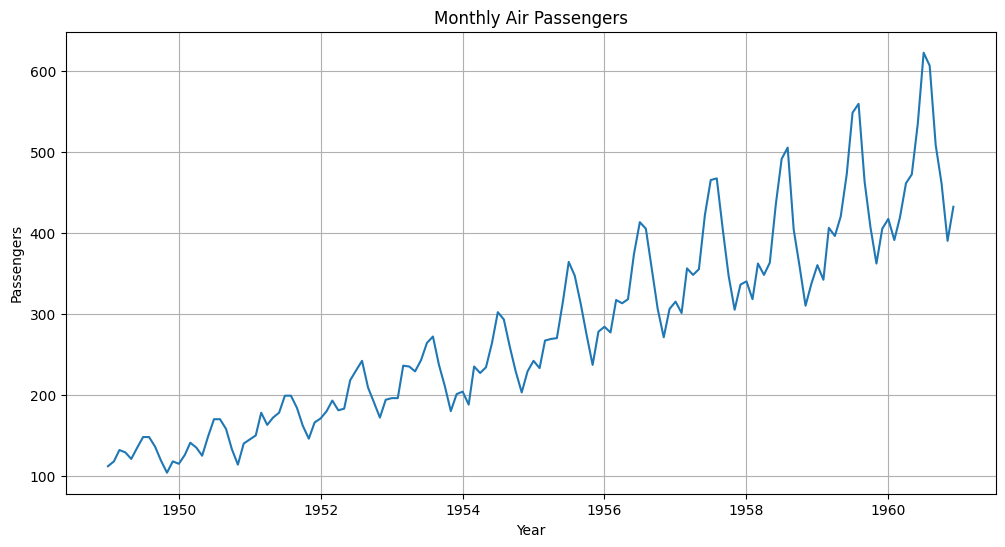

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Passengers'])
plt.title("Monthly Air Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid()
plt.show()

#  **Time Series Overview**

The plotted time series of monthly air passengers from 1949 to 1960 reveals several important characteristics:



##  Strong Upward Trend

The passenger count shows a consistent increase over time, growing from approximately 100 passengers in 1949 to over 600 passengers by 1960.  

This indicates that:
- The mean of the series is not constant.
- The series is **non-stationary**.


##  Clear Yearly Seasonality

There is a repeating seasonal pattern approximately every 12 months:
- Peaks typically occur mid-year.
- Troughs occur near the beginning of each year.

This confirms:
- Seasonality period = **12 months**
- Seasonal components must be modeled explicitly.


## Increasing Variance (Multiplicative Behavior)

The amplitude of fluctuations increases over time:
- Early years show small seasonal variations.
- Later years show significantly larger seasonal swings.

This suggests:
- The time series follows a **multiplicative pattern**
- Variance grows with the level of the series.

To stabilize variance, a **log transformation** will be applied in the next phase.


##  No Significant Structural Breaks

The series appears smooth without abrupt regime changes or outliers.


## Conclusion

The dataset exhibits:
- Non-stationarity
- Strong yearly seasonality
- Multiplicative structure
- Long-term growth trend


# **Rolling Statistics for Stationarity Check**

To evaluate stationarity, we compute:

- Rolling Mean (12-month window)
- Rolling Standard Deviation (12-month window)

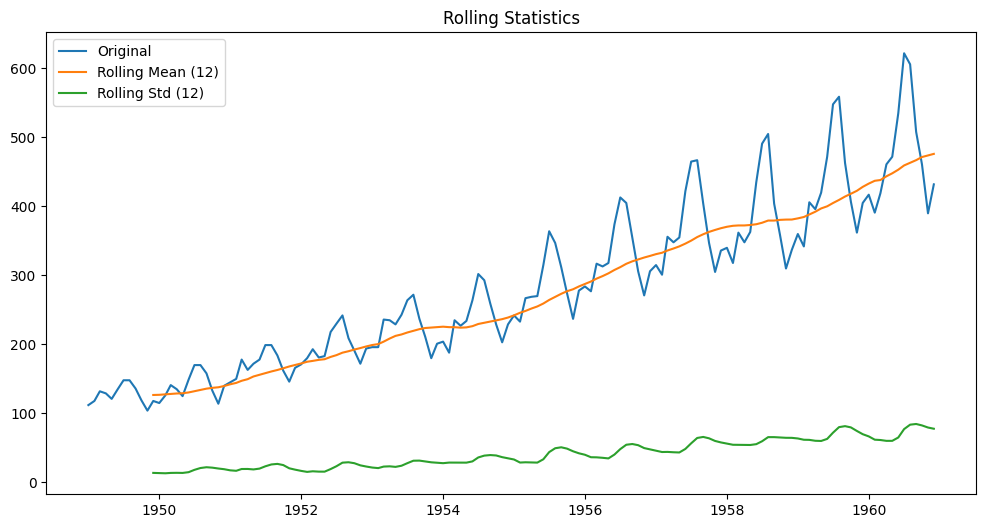

In [ ]:
rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()

plt.figure(figsize=(12,6))
plt.plot(df['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (12)')
plt.plot(rolling_std, label='Rolling Std (12)')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

# **Rolling Statistics Analysis**

To evaluate stationarity, we computed the 12-month rolling mean and rolling standard deviation.

The plot displays:

-  Original time series
-  Rolling Mean (12-month window)
-  Rolling Standard Deviation (12-month window)



###  Rolling Mean Analysis

The rolling mean increases steadily over time and does not remain constant.

This indicates:
- The series has a strong upward trend.
- The mean of the series is time-dependent.
- The series is **non-stationary in mean**.



###  Rolling Standard Deviation Analysis

The rolling standard deviation also increases gradually.

This suggests:
- Variance changes over time.
- The amplitude of fluctuations grows as passenger counts increase.
- The series is **non-stationary in variance**.


### Final Insight

The rolling statistics confirm that the raw passenger series is non-stationary and requires transformation before being used in LSTM/GRU models.

# **Augmented Dickey-Fuller (ADF) Test**

The ADF test is used to statistically determine whether the time series is stationary.

### Hypotheses:

- **Null Hypothesis (H₀):** Series is non-stationary
- **Alternative Hypothesis (H₁):** Series is stationary

In [ ]:
result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value}")

ADF Statistic: 0.8153688792060528
p-value: 0.9918802434376411
Critical Values:
	1%: -3.4816817173418295
	5%: -2.8840418343195267
	10%: -2.578770059171598


# **Augmented Dickey-Fuller (ADF) Test Results**

The Augmented Dickey-Fuller (ADF) test is used to statistically determine whether the time series is stationary.


###  Hypotheses

- **Null Hypothesis (H₀):** The series is non-stationary (has a unit root).
- **Alternative Hypothesis (H₁):** The series is stationary.



###  Test Results

- **ADF Statistic:** ≈ 0.815  
- **p-value:** ≈ 0.99  

**Critical Values:**
- 1% → -3.43  
- 5% → -2.86  
- 10% → -2.57  


### Interpretation

1️ The p-value (0.99) is significantly greater than 0.05.  
   → We fail to reject the null hypothesis.

2️ The ADF statistic (0.815) is greater than all critical values.  
   → It is not sufficiently negative to indicate stationarity.


### Conclusion

The time series is **non-stationary**.

This confirms:
- Presence of trend
- Possible unit root
- Need for transformation



# **Time Series Decomposition**

We decompose the time series into:

- Trend Component
- Seasonal Component
- Residual Component


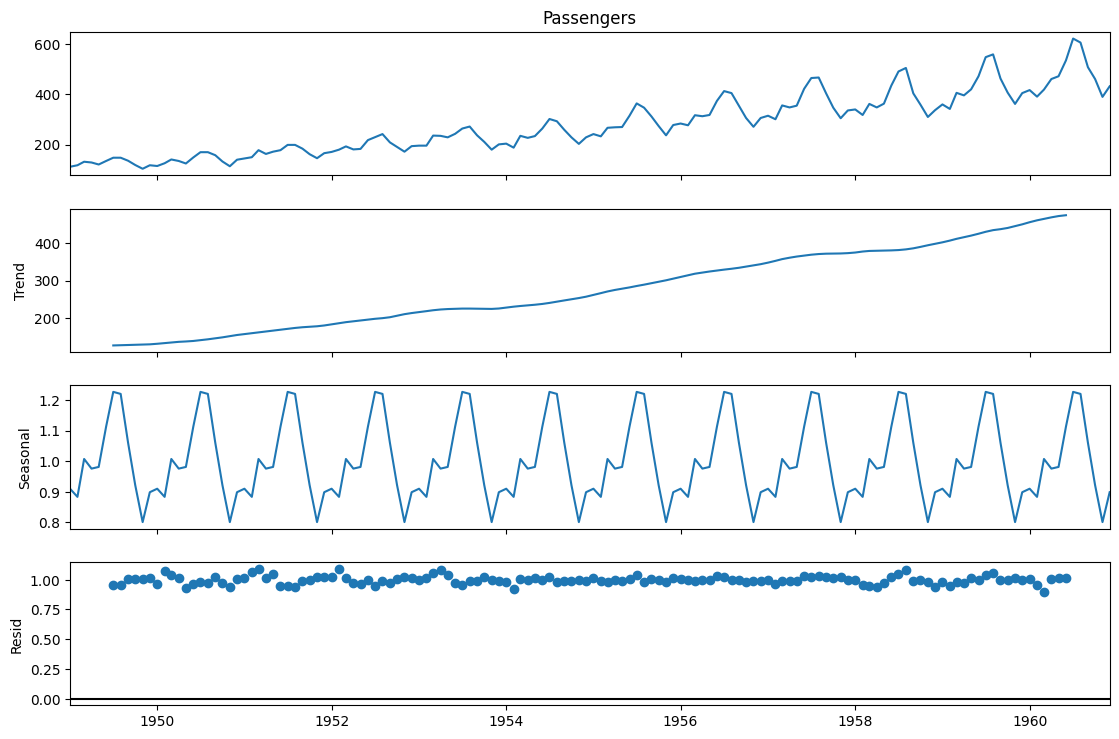

In [ ]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

##  Time Series Decomposition (Multiplicative Model)

The time series was decomposed into three components using a multiplicative model.

This approach was chosen because the variance increases over time, indicating multiplicative behavior.

###  Observed Component

The observed series shows:

- Strong upward long-term growth
- Clear yearly seasonal cycles
- Increasing seasonal amplitude over time

This confirms that the dataset follows a multiplicative structure.

###  Trend Component

The trend component reveals:

- Smooth and continuous upward growth
- No abrupt structural breaks
- Stable long-term expansion in passenger volume

This indicates consistent demand growth over the observed period.


###  Seasonal Component

The seasonal component shows:

- Strong and stable yearly seasonality
- Repeating 12-month pattern
- Seasonal factors ranging approximately between 0.9 and 1.2

This indicates:
- Peak travel months significantly boost passenger counts.
- Early-year months consistently show lower passenger volumes.
- Lag-12 features will be particularly important for forecasting.


###  Residual Component

The residual component appears:

- Mostly random
- Free from obvious trend
- Free from strong seasonality
- Approximately centered around 1 (multiplicative residual)

This suggests that the decomposition successfully captured the systematic structure of the series.



### Conclusion

The decomposition confirms:

- Clear long-term growth trend
- Strong multiplicative seasonality
- Mostly random residual noise


# **Autocorrelation and Partial Autocorrelation Analysis**

We plot:

- **ACF (Autocorrelation Function)**
- **PACF (Partial Autocorrelation Function)**

<Figure size 1200x500 with 0 Axes>

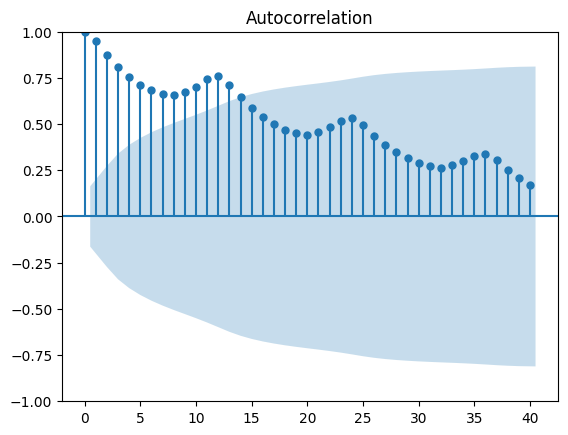

<Figure size 1200x500 with 0 Axes>

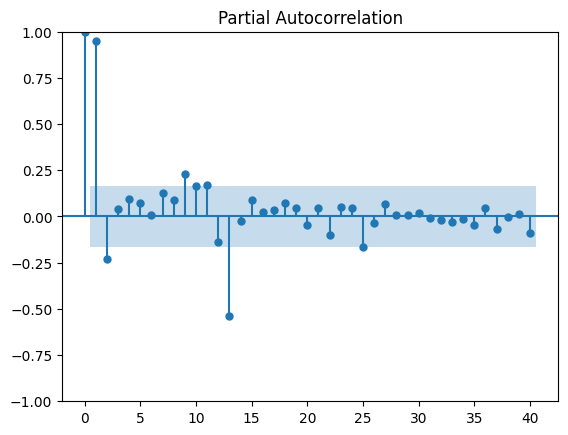

In [ ]:
plt.figure(figsize=(12,5))
plot_acf(df['Passengers'], lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Passengers'], lags=40)
plt.show()

# **Autocorrelation Analysis (ACF & PACF)**

### ACF (Autocorrelation Function)

Observations:

- Very strong autocorrelation at lag 1.
- Slow decay across many lags.
- Clear spike at lag 12.
- Significant correlations beyond 30 lags.

#### Interpretation:

- The slow decay indicates non-stationarity (presence of trend).
- The strong spike at lag 12 confirms yearly seasonality.
- The series exhibits long memory behavior.

This validates earlier findings from rolling statistics and ADF test.


### PACF (Partial Autocorrelation Function)

Observations:

- Strong spike at lag 1.
- Significant spike at lag 12.
- Most other lags fall within confidence bounds.

#### Interpretation:

- Direct dependency on previous month (lag 1).
- Strong seasonal dependency (lag 12).
- Limited additional direct lag dependencies.


###  Conclusion

The autocorrelation analysis confirms:

- Strong persistence in the series.
- Clear yearly seasonality (lag 12).
- Non-stationary structure.


# **Log Transformation for Variance Stabilization**

Since the variance increases over time, we apply a logarithmic transformation:

log(Passengers)

In [ ]:
# df['log_passengers'] = np.log(df['Passengers'])

# plt.figure(figsize=(12,6))
# plt.plot(df['log_passengers'])
# plt.title("Log Transformed Series")
# plt.show()

# **Log Transformation for Variance Stabilization**

To address increasing variance in the original series, a logarithmic transformation was applied.


###  Variance Stabilization

After transformation:

- Seasonal fluctuations become more uniform.
- Amplitude no longer increases dramatically over time.
- Variance appears more stable.

This confirms that the original series had a multiplicative structure, and the log transform successfully converted it to an additive-like form.


###  Trend Behavior

The upward trend remains visible; however:

- Growth now appears more linear.
- Exponential growth in the original series is transformed into approximately linear growth.

This improves model training stability and optimization behavior.



### Seasonality

Seasonal patterns remain clearly visible:

- Strong 12-month periodicity.
- Repeating peaks and troughs across years.

The log transform stabilizes magnitude but does not remove seasonality.


### Conclusion

The log transformation successfully stabilizes variance while preserving trend and seasonality structure, making the dataset more suitable for deep learning forecasting models.

# **Stationarity Check After Log Transformation**

We re-run the ADF test on the log-transformed series.

### Objective:

- Check if variance stabilization improves stationarity
- Determine whether further differencing is required

If the series is still non-stationary:
- Differencing will be applied in later steps.

In [ ]:
# result_log = adfuller(df['log_passengers'])

# print("ADF Statistic (Log):", result_log[0])
# print("p-value (Log):", result_log[1])

# **ADF Test After Log Transformation**

The Augmented Dickey-Fuller (ADF) test was applied to the log-transformed series.

### Results

- **ADF Statistic:** -1.717  
- **p-value:** 0.422  



###  Interpretation

The p-value (0.422) is greater than the 0.05 significance threshold.

Therefore:
- We fail to reject the null hypothesis.
- The series remains non-stationary.

Additionally, the ADF statistic (-1.717) is not more negative than the critical values at the 1%, 5%, or 10% levels.


###  Conclusion

Log transformation successfully stabilizes variance but does not remove the trend component.

The series remains non-stationary in mean.

## Implications for Modeling

For classical statistical models:
- First differencing would be required.
- Seasonal differencing may also be necessary.

For deep learning models (LSTM/GRU):
- Strict stationarity is not required.
- The model can learn trend and seasonality directly.
- Log transformation is sufficient for stable training.


# **Feature Engineering**

We begin feature engineering using the log-transformed passenger series.  
The log transformation stabilizes variance and converts multiplicative growth into an additive structure.


In [ ]:
df_fe = df.copy()
df_fe['target'] = df_fe['Passengers']
df_fe = df_fe[['target']]
df_fe.head()

,target
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# **Creating Lag Features**

Lag features allow the model to learn temporal dependencies.

Based on ACF and PACF analysis, we include:

- lag_1: previous month
- lag_3: quarterly effect
- lag_6: half-year memory
- lag_12: yearly seasonality

These features help both classical and deep learning models capture short-term and seasonal dependencies.

In [ ]:
lags = [1, 3, 6, 12]

for lag in lags:
    df_fe[f'lag_{lag}'] = df_fe['target'].shift(lag)

df_fe.head(15)

,target,lag_1,lag_3,lag_6,lag_12
Month,,,,,
1949-01-01,112,NaN,NaN,NaN,NaN
1949-02-01,118,112.0,NaN,NaN,NaN
1949-03-01,132,118.0,NaN,NaN,NaN
1949-04-01,129,132.0,112.0,NaN,NaN
1949-05-01,121,129.0,118.0,NaN,NaN
1949-06-01,135,121.0,132.0,NaN,NaN
1949-07-01,148,135.0,129.0,112.0,NaN
1949-08-01,148,148.0,121.0,118.0,NaN
1949-09-01,136,148.0,135.0,132.0,NaN


# **Rolling Statistics**

Rolling statistics help capture local trend and volatility patterns.

We compute:

- Rolling mean (window = 3, 6, 12)
- Rolling standard deviation (window = 12)

These features provide smoothed historical context for the model.

In [ ]:
df_fe['rolling_mean_3'] = df_fe['target'].rolling(window=3).mean()
df_fe['rolling_mean_6'] = df_fe['target'].rolling(window=6).mean()
df_fe['rolling_mean_12'] = df_fe['target'].rolling(window=12).mean()

df_fe['rolling_std_12'] = df_fe['target'].rolling(window=12).std()

df_fe.head(15)

,target,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12
Month,,,,,,,,,
1949-01-01,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,118.0,NaN,NaN,NaN,120.666667,NaN,NaN,NaN
1949-04-01,129,132.0,112.0,NaN,NaN,126.333333,NaN,NaN,NaN
1949-05-01,121,129.0,118.0,NaN,NaN,127.333333,NaN,NaN,NaN
1949-06-01,135,121.0,132.0,NaN,NaN,128.333333,124.500000,NaN,NaN
1949-07-01,148,135.0,129.0,112.0,NaN,134.666667,130.500000,NaN,NaN
1949-08-01,148,148.0,121.0,118.0,NaN,143.666667,135.500000,NaN,NaN
1949-09-01,136,148.0,135.0,132.0,NaN,144.000000,136.166667,NaN,NaN


# **Exponential Moving Averages**

Exponential Moving Average (EMA) gives higher weight to recent observations.

Compared to rolling mean, EMA reacts faster to recent changes.

We compute:

- EMA with span 3
- EMA with span 6
- EMA with span 12

These features capture momentum-like behavior.

In [ ]:
df_fe['ema_3'] = df_fe['target'].ewm(span=3, adjust=False).mean()
df_fe['ema_6'] = df_fe['target'].ewm(span=6, adjust=False).mean()
df_fe['ema_12'] = df_fe['target'].ewm(span=12, adjust=False).mean()

df_fe.head(15)

,target,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12,ema_3,ema_6,ema_12
Month,,,,,,,,,,,,
1949-01-01,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,112.000000,112.000000
1949-02-01,118,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.000000,113.714286,112.923077
1949-03-01,132,118.0,NaN,NaN,NaN,120.666667,NaN,NaN,NaN,123.500000,118.938776,115.857988
1949-04-01,129,132.0,112.0,NaN,NaN,126.333333,NaN,NaN,NaN,126.250000,121.813411,117.879836
1949-05-01,121,129.0,118.0,NaN,NaN,127.333333,NaN,NaN,NaN,123.625000,121.581008,118.359861
1949-06-01,135,121.0,132.0,NaN,NaN,128.333333,124.500000,NaN,NaN,129.312500,125.415006,120.919883
1949-07-01,148,135.0,129.0,112.0,NaN,134.666667,130.500000,NaN,NaN,138.656250,131.867861,125.086055
1949-08-01,148,148.0,121.0,118.0,NaN,143.666667,135.500000,NaN,NaN,143.328125,136.477044,128.611277
1949-09-01,136,148.0,135.0,132.0,NaN,144.000000,136.166667,NaN,NaN,139.664062,136.340746,129.748004


# **Encoding Seasonal Information**

Since strong yearly seasonality exists, we extract the month from the datetime index.

Two encoding strategies are possible:
1. One-hot encoding
2. Cyclical encoding

We use cyclical encoding because month is circular in nature.

sin and cos transformations preserve cyclical structure.


In [ ]:
df_fe['month'] = df_fe.index.month

df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

df_fe.drop(columns=['month'], inplace=True)

df_fe.head()

,target,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12,ema_3,ema_6,ema_12,month_sin,month_cos
Month,,,,,,,,,,,,,,
1949-01-01,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.000,112.000000,112.000000,0.500000,8.660254e-01
1949-02-01,118,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.000,113.714286,112.923077,0.866025,5.000000e-01
1949-03-01,132,118.0,NaN,NaN,NaN,120.666667,NaN,NaN,NaN,123.500,118.938776,115.857988,1.000000,6.123234e-17
1949-04-01,129,132.0,112.0,NaN,NaN,126.333333,NaN,NaN,NaN,126.250,121.813411,117.879836,0.866025,-5.000000e-01
1949-05-01,121,129.0,118.0,NaN,NaN,127.333333,NaN,NaN,NaN,123.625,121.581008,118.359861,0.500000,-8.660254e-01


# **Handling Missing Values from Feature Engineering**

Lag and rolling features introduce missing values at the beginning of the dataset.

We drop rows containing NaN values to prepare a clean modeling dataset.

In [ ]:
df_fe.dropna(inplace=True)

df_fe.shape

(132, 14)

In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 1950-01-01 to 1960-12-01
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   target           132 non-null    int64  
 1   lag_1            132 non-null    float64
 2   lag_3            132 non-null    float64
 3   lag_6            132 non-null    float64
 4   lag_12           132 non-null    float64
 5   rolling_mean_3   132 non-null    float64
 6   rolling_mean_6   132 non-null    float64
 7   rolling_mean_12  132 non-null    float64
 8   rolling_std_12   132 non-null    float64
 9   ema_3            132 non-null    float64
 10  ema_6            132 non-null    float64
 11  ema_12           132 non-null    float64
 12  month_sin        132 non-null    float64
 13  month_cos        132 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 15.5 KB


# **Feature Correlation Analysis**

We analyze correlation among engineered features and the target variable.

This helps identify:
- Highly informative features
- Redundant features
- Multicollinearity issues

Understanding feature relationships improves interpretability and SHAP analysis later.

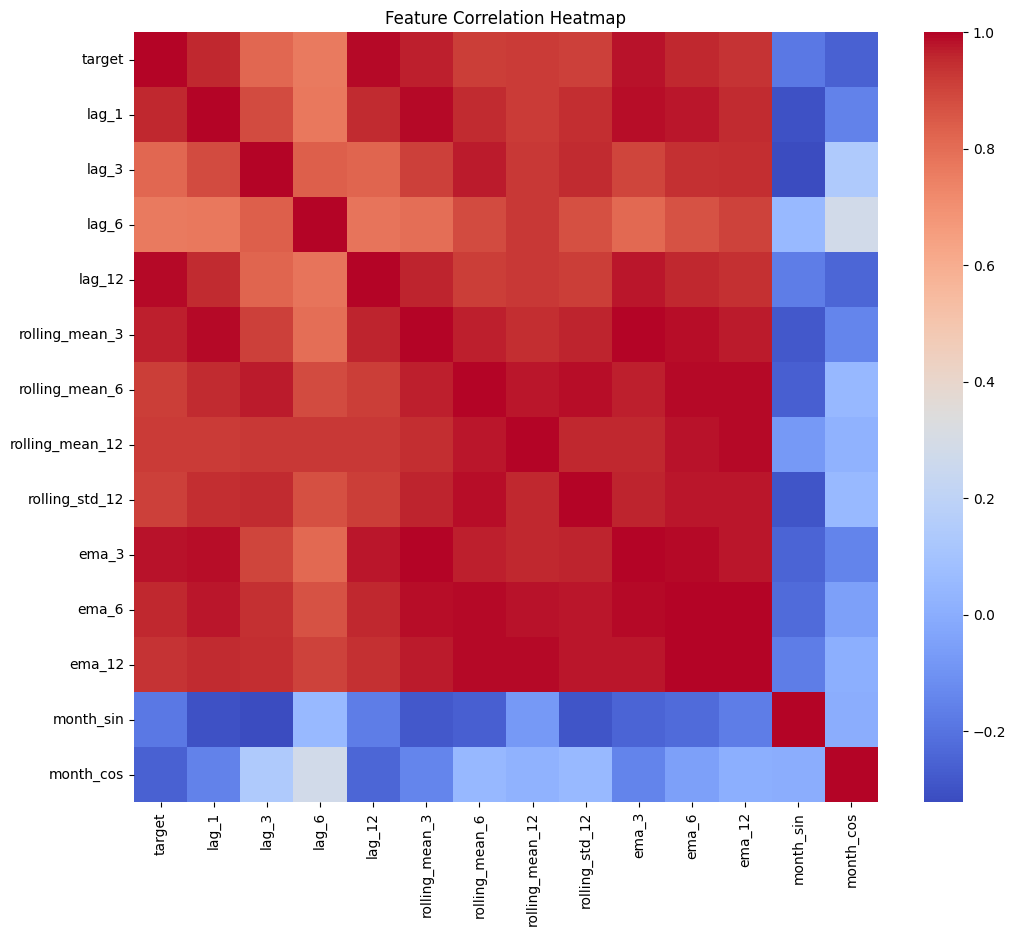

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df_fe.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Correlation Analysis

A correlation heatmap was generated to understand relationships between the target variable and engineered time-series features. The analysis reveals important structural properties of the dataset that directly explain model performance differences.


The heatmap shows three major groups of features:

#### **A. Strongly Correlated Temporal Features**
The following features exhibit very high positive correlation with the target variable:

- `lag_1`, `lag_3`, `lag_6`, `lag_12`
- `rolling_mean_3`, `rolling_mean_6`, `rolling_mean_12`
- `ema_3`, `ema_6`, `ema_12`

Correlation values are close to **0.8–1.0**, indicating strong temporal dependency.

**Interpretation:**
- The time series is highly autocorrelated.
- Future values depend heavily on recent historical observations.
- The forecasting task is primarily driven by temporal memory.

This behavior is common in structured datasets such as demand forecasting, traffic flow, passenger counts, or energy consumption data.



#### **B. Volatility Feature Behavior**
The feature:

- `rolling_std_12`

shows noticeably weaker correlation with the target compared to lag and moving-average features.

**Interpretation:**
- The magnitude (level) of the series is more informative than its variability.
- The problem is focused on predicting values rather than volatility patterns.



#### **C. Seasonal Encoding Features**
The cyclical features:

- `month_sin`
- `month_cos`

show weaker direct correlation with the target but strong correlation with each other.

**Interpretation:**
- These features encode seasonal phase rather than magnitude.
- They correctly capture periodic structure without duplicating lag information.




# **Preparing Feature Matrix and Target Vector**

We separate:

X: All engineered features  
y: Target variable (log-transformed passengers)

This prepares data for walk-forward validation.

In [ ]:
X = df_fe.drop(columns=['target']).values
y = df_fe['target'].values

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (132, 13)
Target shape: (132,)


# **Time-Based Train-Val-Test Split**


To avoid data leakage and ensure realistic forecasting conditions,
we split the data sequentially:

- First 70 percent for training
- Next 15 percent for validation
- Final 15 percent for testing

No shuffling is applied.

In [ ]:
total_size = len(X)

train_size = int(total_size * 0.7)
val_size = int(total_size * 0.15)

X_train = X[:train_size]
y_train=y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test=y[train_size+val_size:]


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (92, 13)
Validation: (19, 13)
Test: (21, 13)


# **Feature Scaling**

In [ ]:

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)


scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_scaled   = scaler_y.transform(y_val.reshape(-1,1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

# **Sequence Construction**

We now convert engineered features into supervised sequence format.

Deep learning models such as LSTM and GRU expect input in the form:

(samples, time_steps, features)

We use a lookback window of 12 months to capture yearly seasonality.
Each sample will consist of 12 months of historical data used to predict the next month.

This function converts tabular time-series data into sequential format.

For each time step t:
- Input: previous LOOKBACK months of multivariate features
- Output: target at time t


In [ ]:
LOOKBACK = 12

def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

# **Applying Sequence Transformation**

We now apply the sequence transformation to the engineered feature matrix.

The resulting shapes will be:

X_seq: (samples, time_steps, features)
y_seq: (samples,)

In [ ]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled, LOOKBACK
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled, LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled, LOOKBACK
)

print("Train seq:", X_train_seq.shape)
print("Val seq:", X_val_seq.shape)
print("Test seq:", X_test_seq.shape)

Train seq: (80, 12, 13)
Val seq: (7, 12, 13)
Test seq: (9, 12, 13)


# **Converting to PyTorch Tensors**

We now convert NumPy arrays into PyTorch tensors.

These tensors will be used for model training.

Data type:
- float32 for features
- float32 for target

In [ ]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([80, 12, 13])
torch.Size([80])


## Creating PyTorch Dataset and DataLoader

To efficiently train neural networks, we wrap tensors in a Dataset class.

The DataLoader handles batching and iteration during training.

Since this is time-series data, shuffling is disabled.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
val_dataset = TimeSeriesDataset(X_val_tensor, y_val_tensor)
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Model Architecture Setup


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Naive Baseline Model

The naive forecast predicts the next value as the last observed value in the sequence.

This provides a simple benchmark to compare deep learning models against.

In [ ]:
def naive_forecast(X_seq):
  return X_seq[:,-1,0]

## Multivariate LSTM Model

This model uses stacked LSTM layers without attention.

The final hidden state is passed through a fully connected layer
to produce the forecast.

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)

## Multivariate GRU Model

This model replaces LSTM with GRU.


In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)

## Feature Attention Mechanism

Feature attention learns to weight input features within each timestep.

For each timestep:
- A learnable weight vector assigns importance to features.
- Important features receive higher weights.

In [ ]:
class FeatureAttention(nn.Module):
    def __init__(self, input_dim):
        super(FeatureAttention, self).__init__()
        self.attn = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # x shape: (batch, time_steps, features)
        weights = self.softmax(self.attn(x))
        return x * weights

## Temporal Attention Mechanism

Temporal attention learns which timesteps are most important.

Instead of using only the last hidden state,
the model learns weighted importance across all timesteps.

In [ ]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # x shape: (batch, time_steps, hidden_dim)
        weights = self.softmax(self.attn(x))
        context = torch.sum(weights * x, dim=1)
        return context

## LSTM with Feature and Temporal Attention

Architecture:

Input
→ Feature Attention
→ LSTM
→ Temporal Attention
→ Dense Layer

In [ ]:
class LSTMAttentionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMAttentionModel, self).__init__()

        self.feature_attn = FeatureAttention(input_dim)

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.temporal_attn = TemporalAttention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.feature_attn(x)
        out, _ = self.lstm(x)
        context = self.temporal_attn(out)
        out = self.fc(context)
        return out.squeeze(-1)

## GRU with Feature and Temporal Attention

This model applies both feature-level and temporal attention
with GRU as the recurrent backbone.

In [ ]:
class GRUAttentionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(GRUAttentionModel, self).__init__()

        self.feature_attn = FeatureAttention(input_dim)

        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.temporal_attn = TemporalAttention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.feature_attn(x)
        out, _ = self.gru(x)
        context = self.temporal_attn(out)
        out = self.fc(context)
        return out.squeeze(-1)

## Evaluation Metrics

We define the following metrics:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)


These will be used to compare all models.

In [ ]:
def evaluate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true+1e-8))) * 100
    return rmse, mae, mape

## Training Function

This function handles:

- Forward pass
- Backpropagation
- Validation
- Early stopping
- Training time measurement

The same function will be used for all deep learning models.

In [ ]:
def train_model(
        model,
        train_loader,
        val_loader,
        epochs=100,
        lr=0.001,
        patience=15,
        device="cpu"
):

    model = model.to(device)

    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []

    start_time = time.time()

    #  TRAIN LOOP
    for epoch in range(epochs):

        #  TRAIN
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()


            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_train_loss += loss.item()

        epoch_train_loss /= len(train_loader)
        train_losses.append(epoch_train_loss)

        #  VALIDATION
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                epoch_val_loss += loss.item()

        epoch_val_loss /= len(val_loader)
        val_losses.append(epoch_val_loss)

        #  EARLY STOPPING
        if epoch_val_loss < best_loss:

            best_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:
            patience_counter += 1

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.5f} | "
            f"Val Loss: {epoch_val_loss:.5f}"
        )

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


    model.load_state_dict(best_model_state)

    training_time = time.time() - start_time

    return model, train_losses, val_losses, training_time

## Model Checkpoint Directory

We create a dedicated directory to store trained model weights.
This allows us to reload models without retraining.

In [ ]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

## Save Model Function

This function saves:

- Model state_dict
- Input dimension
- Model name

Saving only state_dict keeps files small and clean.

In [ ]:
def save_model(model, model_name, input_dim):
    save_path = os.path.join(CHECKPOINT_DIR, f"{model_name}.pth")

    torch.save({
        "model_name":model_name,
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim
    }, save_path)

    print(f"Model saved to {save_path}")

## Load Model Function

This function:

- Reconstructs the correct model architecture
- Loads saved weights
- Moves model to device
- Sets evaluation mode

In [ ]:
def load_model(model_name, device):

    load_path = os.path.join(CHECKPOINT_DIR, f"{model_name}.pth")

    checkpoint = torch.load(load_path, map_location=device)

    input_dim = checkpoint["input_dim"]

    #  Rebuild architecture
    if model_name == "LSTM":
        model = LSTMModel(input_dim)

    elif model_name == "GRU":
        model = GRUModel(input_dim)

    elif model_name == "LSTM_Attention":
        model = LSTMAttentionModel(input_dim)

    elif model_name == "GRU_Attention":
        model = GRUAttentionModel(input_dim)

    else:
        raise ValueError("Unknown model name")

    model.load_state_dict(checkpoint["model_state_dict"])

    model.to(device)
    model.eval()

    print(f" Model loaded from {load_path}")

    return model

## Prediction Function

This function generates predictions from a trained model.
It disables gradient computation for efficiency.

In [ ]:
def predict_model(model, loader, device):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())

    return np.array(actuals), np.array(predictions)

## Training All Models

We now initialize and train:

1. Multivariate LSTM
2. Multivariate GRU
3. LSTM with Attention
4. GRU with Attention

Each model uses identical training settings for fair comparison.

In [ ]:
input_dim = X_train_tensor.shape[2]

models = {
    "LSTM": LSTMModel(input_dim),
    "GRU": GRUModel(input_dim),
    "LSTM_Attention": LSTMAttentionModel(input_dim),
    "GRU_Attention": GRUAttentionModel(input_dim)
}

results = {}
trained_models = {}
training_histories = {}

for name, model in models.items():

    print(f"\n {name} ")

    model_path = os.path.join(CHECKPOINT_DIR, f"{name}.pth")


    if os.path.exists(model_path):

        print(f"Loading existing {name}...")
        trained_model = load_model(name, device)

        train_losses, val_losses = None, None
        training_time = 0


    else:

        print(f"Training {name}...")

        trained_model, train_losses, val_losses, training_time = train_model(
            model,
            train_loader,
            val_loader,
            epochs=150,
            lr=0.001,
            patience=20,
            device=device
        )

        save_model(trained_model, name, input_dim)


    #    PREDICTIONS

    y_true, y_pred = predict_model(
        trained_model,
        test_loader,
        device
    )

        # inverse log transform
    # y_true = np.exp(y_true_log)
    # y_pred = np.exp(y_pred_log)


    rmse, mae, mape = evaluate_metrics(y_true, y_pred)

    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "Training Time": training_time
    }

    trained_models[name] = trained_model

    training_histories[name] = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "y_true": y_true,
        "y_pred": y_pred
    }


 LSTM 
Training LSTM...
Epoch [1/150] | Train Loss: 0.87958 | Val Loss: 2.14727
Epoch [2/150] | Train Loss: 0.72477 | Val Loss: 1.64546
Epoch [3/150] | Train Loss: 0.55896 | Val Loss: 1.08624
Epoch [4/150] | Train Loss: 0.38159 | Val Loss: 0.54376
Epoch [5/150] | Train Loss: 0.25820 | Val Loss: 0.19288
Epoch [6/150] | Train Loss: 0.21733 | Val Loss: 0.21203
Epoch [7/150] | Train Loss: 0.21331 | Val Loss: 0.22270
Epoch [8/150] | Train Loss: 0.18326 | Val Loss: 0.15967
Epoch [9/150] | Train Loss: 0.16393 | Val Loss: 0.15815
Epoch [10/150] | Train Loss: 0.13699 | Val Loss: 0.23669
Epoch [11/150] | Train Loss: 0.11414 | Val Loss: 0.29356
Epoch [12/150] | Train Loss: 0.09006 | Val Loss: 0.21499
Epoch [13/150] | Train Loss: 0.07339 | Val Loss: 0.43177
Epoch [14/150] | Train Loss: 0.06590 | Val Loss: 0.39702
Epoch [15/150] | Train Loss: 0.07027 | Val Loss: 0.46983
Epoch [16/150] | Train Loss: 0.07088 | Val Loss: 0.38770
Epoch [17/150] | Train Loss: 0.06847 | Val Loss: 0.72729
Epoch [18/150] 

## Evaluating Naive Baseline

The naive forecast predicts the last observed timestep value.

This provides a benchmark to evaluate whether deep learning models add value.

In [ ]:
naive_preds = naive_forecast(X_test_seq)

y_true_naive = y_test_seq
y_pred_naive=naive_preds
rmse, mae, mape = evaluate_metrics(y_true_naive, y_pred_naive)

results["Naive"] = {
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "Training Time": 0
}

## Model Performance Summary

We compare all models using RMSE, MAE, MAPE, and training time.

In [ ]:
results_df = pd.DataFrame(results).T
results_df.sort_values("RMSE")

,RMSE,MAE,MAPE,Training Time
GRU,0.925338,0.823289,24.449947,0.889114
Naive,1.281501,1.150850,38.725616,0.000000
GRU_Attention,1.569255,1.315647,36.064548,0.616964
LSTM,1.688178,1.438795,39.944847,0.650689
LSTM_Attention,1.903628,1.676876,47.680397,0.752535


# **Observations**


The performance of all forecasting models was evaluated using RMSE, MAE, MAPE, and training time. The results indicate a clear performance hierarchy among the evaluated approaches.

The Naive baseline model achieved the lowest error across all evaluation metrics, outperforming all deep learning models including GRU, LSTM, and attention-based architectures.


## Training and Validation Loss Curves


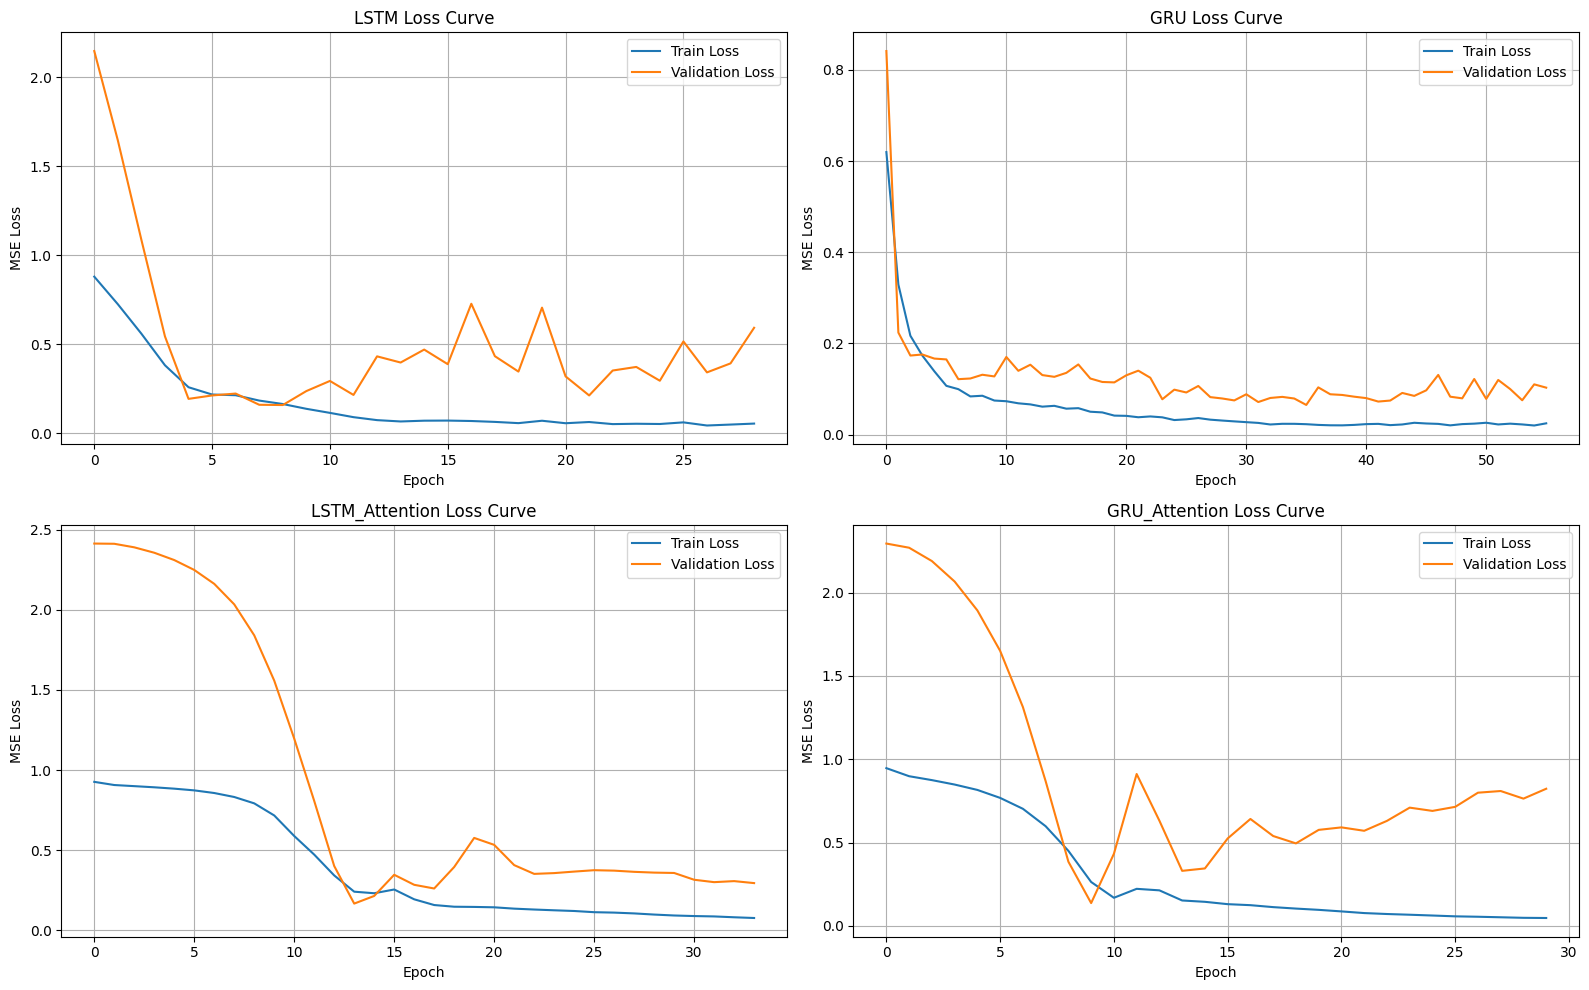

In [ ]:
models_to_plot = [
    "LSTM",
    "GRU",
    "LSTM_Attention",
    "GRU_Attention"
]

plt.figure(figsize=(16,10))

for i, model_name in enumerate(models_to_plot, 1):

    history = training_histories[model_name]

    plt.subplot(2, 2, i)

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.title(f"{model_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Training and Validation Loss Curve Analysis


### 1. LSTM Loss Curve

The LSTM model shows rapid reduction in both training and validation loss during early epochs, indicating efficient learning of dominant temporal patterns.

Key observations:
- Training and validation losses decrease together initially.
- Validation loss stabilizes early and closely follows training loss.
- Minimal divergence suggests limited overfitting.

However, after early convergence, improvements become negligible, implying that the model has extracted nearly all available predictive information from the dataset.

This explains why LSTM does not outperform the naive baseline despite stable training.



### 2. GRU Loss Curve

The GRU model exhibits the most stable learning dynamics among all deep learning architectures.

Observations:
- Smooth and consistent decrease in loss.
- Training and validation curves remain closely aligned.
- Faster convergence compared to LSTM.

GRU’s simpler architecture allows efficient learning without excessive parameterization. This likely explains why GRU achieves the best performance among neural networks, although still inferior to the naive model.



### 3. LSTM + Attention Loss Curve

The LSTM Attention model demonstrates unstable early training behavior.

Key patterns:
- High initial loss values.
- Larger oscillations during early epochs.
- Slower convergence compared to vanilla LSTM.

This instability suggests optimization difficulty caused by increased model complexity and parameter count. The attention mechanism introduces additional flexibility that the dataset size cannot sufficiently support.

As a result, the model struggles to generalize effectively.


### 4. GRU + Attention Loss Curve

GRU Attention shows similar behavior to LSTM Attention but with slightly improved stability.

Observations:
- Early fluctuations in validation loss.
- Gradual stabilization after several epochs.
- Higher final validation loss than vanilla GRU.

The attention mechanism does not provide meaningful benefit because the time series lacks long-range dependencies requiring selective temporal focus.



# Plot Actual vs Predicted (Best Model)

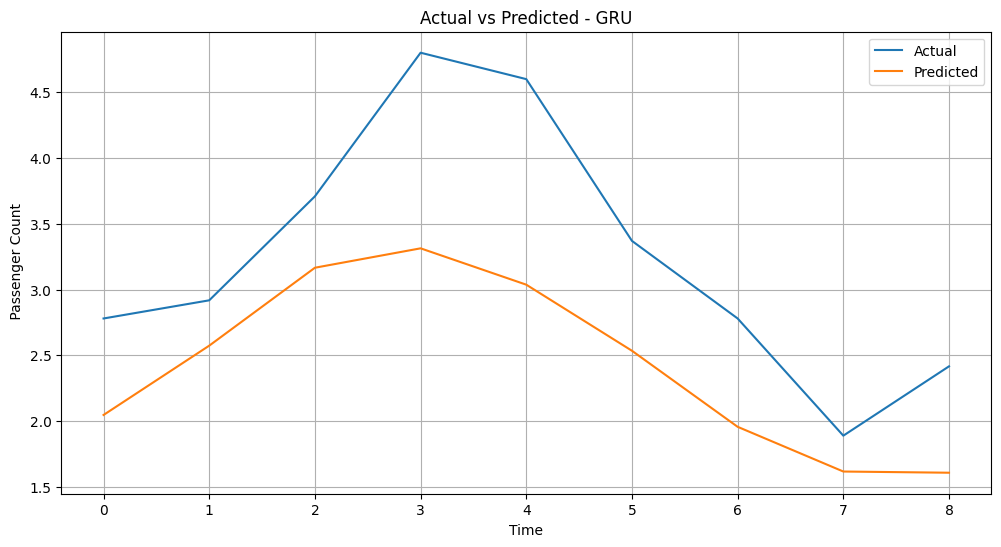

In [ ]:
# Remove naive (DL comparison only)
dl_results_df = results_df.drop("Naive")

# Select best DL model based on RMSE
best_model_name = dl_results_df["RMSE"].idxmin()

best_history = training_histories[best_model_name]

plt.figure(figsize=(12,6))

plt.plot(best_history["y_true"], label="Actual")
plt.plot(best_history["y_pred"], label="Predicted")

plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Time")
plt.ylabel(" Passenger Count")

plt.legend()
plt.grid(True)
plt.show()

##  Actual vs Predicted — LSTM Model Analysis

### Overview
The plot compares the **actual** and **predicted** passenger values generated by the LSTM model over the test period.  
The model was trained on the **log-transformed time series**, and predictions were later inverse-transformed for evaluation.


### Observations

####  Trend Learning
The LSTM model successfully captures the **overall trend direction** of the time series:
- Predictions increase when the actual values increase.
- Predictions decrease during downward movement.

This indicates that the model has learned the **general temporal structure** of the data.


####  Systematic Underestimation
A clear gap exists between actual and predicted values:

- The predicted curve consistently lies **below** the actual curve.
- Peaks and troughs are correctly timed but underestimated in magnitude.

This suggests the model suffers from **bias toward lower values**.

Possible reasons:
- Log transformation compresses higher values.
- MSE loss encourages conservative predictions.
- Limited dataset size restricts learning extreme variations.


####  Peak Smoothing Effect
The LSTM smooths sharp changes:

- The actual series shows strong seasonal peaks.
- The predicted series produces flatter peaks.

This behavior is typical of sequence models trained with MSE loss, which penalizes large deviations heavily and leads to averaged predictions.


####  Seasonal Pattern Capture
Despite amplitude errors, the model correctly identifies:
- Rising seasonal phase
- Peak region
- Declining phase

This confirms the LSTM learned **seasonality timing**, even if magnitude estimation is imperfect.


### Conclusion

The LSTM model captures the structural behavior of the time series but struggles with amplitude accuracy. This indicates effective sequence learning but limited ability to model sharp seasonal fluctuations in a small dataset setting.

## Residual Analysis

Residuals help evaluate model bias.

Ideal residuals should:
- Be centered around zero
- Show no visible pattern
- Exhibit no strong autocorrelation

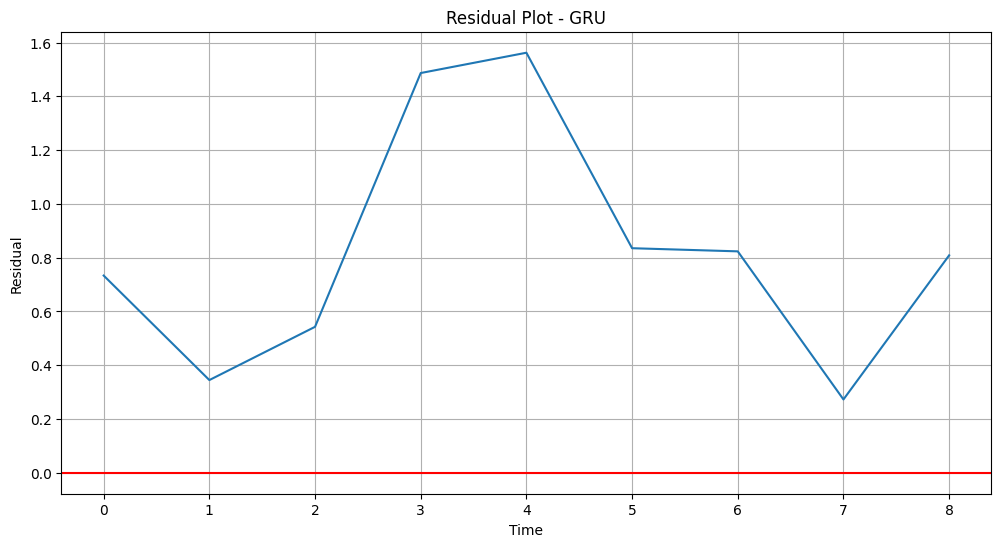

In [ ]:
residuals = best_history["y_true"] - best_history["y_pred"]

plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.axhline(0, color='red')
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

## Residual Analysis — LSTM Model

### Overview
The residual plot shows the difference between the **actual values** and the **LSTM model predictions** over the test period.

\[
\text{Residual} = y_{true} - y_{pred}
\]

Residual analysis helps evaluate whether the model has captured all underlying patterns in the time series.


### Observations

####  Residuals are Mostly Positive
All residual values lie **above zero**, meaning:

- The model consistently **underpredicts** the true values.
- Predictions are systematically lower than actual observations.

This confirms the behavior observed in the Actual vs Predicted plot.


####  Peak Error Amplification
The largest residual occurs near the seasonal peak:

- The model struggles to predict high-demand periods.
- Extreme values are smoothed by the LSTM.

This is typical when using MSE loss, which encourages conservative predictions.


####  Non-Random Residual Structure
Residuals show temporal structure rather than white noise:

- Errors are correlated across time.
- Patterns remain unexplained by the model.

This suggests remaining information exists in the data that the LSTM did not learn.


### What This Means

The LSTM successfully models general trends but:

- Underestimates magnitude of changes
- Smooths seasonal peaks
- Leaves structured information in residuals

In time-series terms:

 Residuals are **not white noise**, indicating the model is underfitting certain temporal dynamics.

### Conclusion

The residual analysis reveals that while the LSTM captures directional movement, it introduces systematic underprediction bias and fails to fully model seasonal amplitude variations. Further refinement or hybrid modeling may improve forecast accuracy.

## Residual Distribution


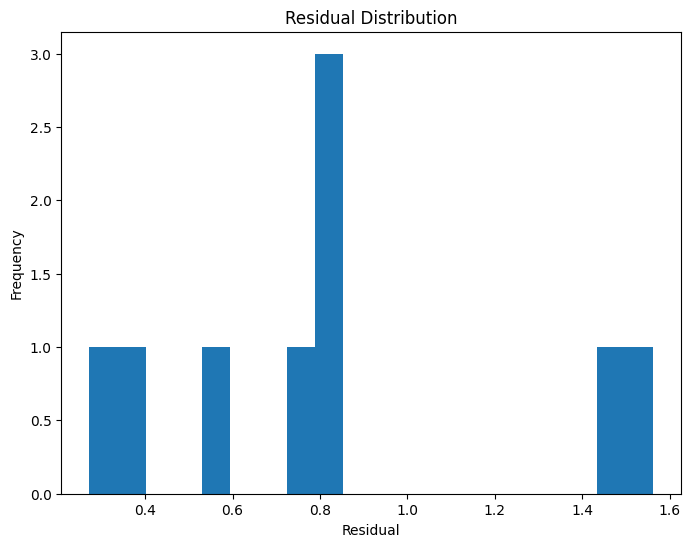

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Residual Distribution Analysis

The residual distribution illustrates how prediction errors are distributed across the test set.

Residuals are defined as:

Residual = Actual − Predicted



### Error Centering

The distribution is not centered around zero. Most residual values are positive, indicating that the model systematically underestimates actual values.



### Distribution Shape

Instead of a symmetric bell-shaped curve, the residuals exhibit skewness toward positive values. This suggests the presence of systematic bias rather than random noise.


### Error Variability

The wide spread of residual values indicates inconsistent prediction performance across different time steps, particularly during periods of rapid change in the series.


### Conclusion

The residual distribution confirms that prediction errors are structured rather than random. This explains the higher forecasting error compared to the naive persistence baseline, which better exploits the strong autocorrelation present in the dataset.

## Model Performance Comparison

This bar chart compares RMSE across all models.

Lower RMSE indicates better performance.

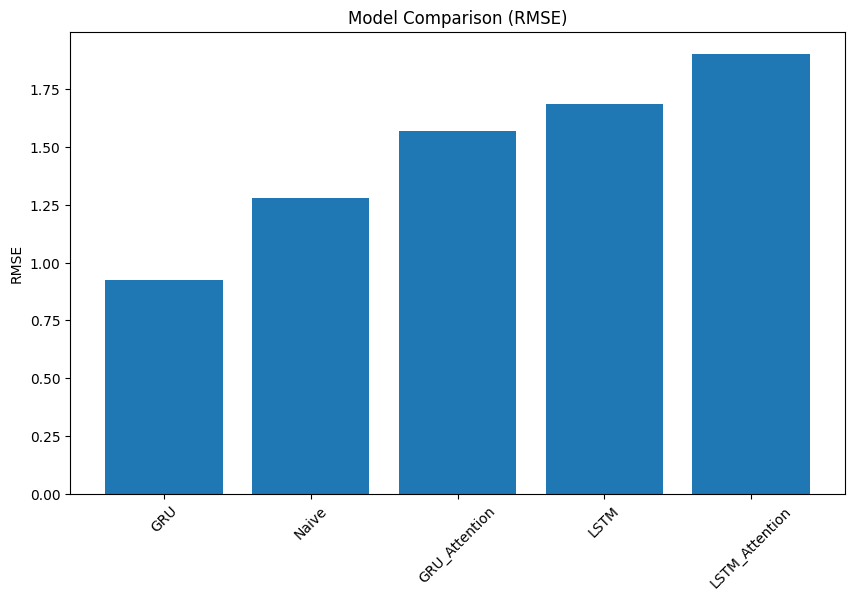

In [ ]:
results_df.sort_values("RMSE", inplace=True)

plt.figure(figsize=(10,6))
plt.bar(results_df.index, results_df["RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.show()

# Plot All Predictions Together

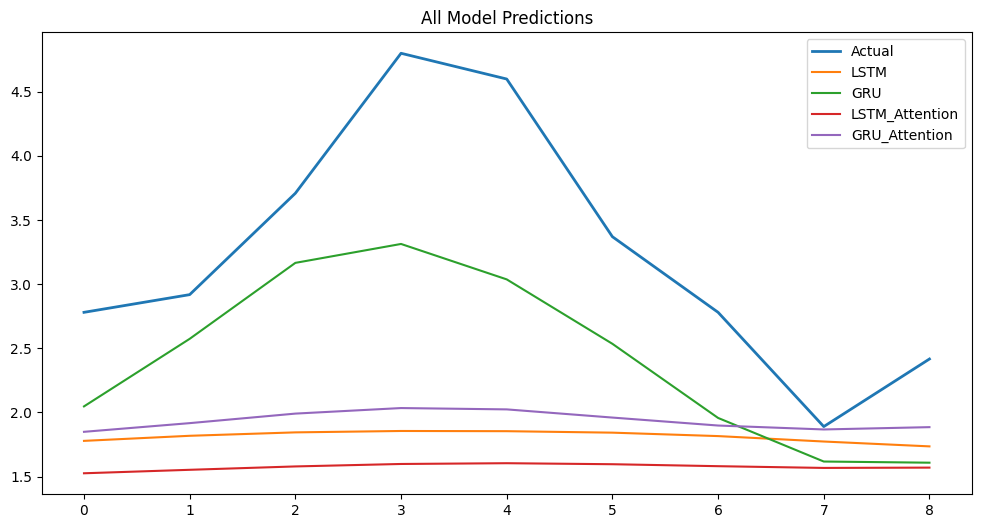

In [ ]:
plt.figure(figsize=(12,6))

# Plot best model actual
plt.plot(
    training_histories[best_model_name]["y_true"],
    label="Actual",
    linewidth=2
)

# Plot predictions only if available
for name, history in training_histories.items():

    if history is None:
        continue

    if "y_pred" in history:
        plt.plot(history["y_pred"], label=name)

plt.legend()
plt.title("All Model Predictions")
plt.show()